In [35]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import folium
import matplotlib.ticker as ticker
from PIL import Image
from wordcloud import WordCloud, STOPWORDS, ImageColorGenerator
import nltk
from nltk.stem import WordNetLemmatizer
from nltk.corpus import stopwords
import re
from sklearn.feature_extraction.text import TfidfVectorizer
from datetime import datetime

sns.set_style("ticks")
sns.color_palette(palette='Paired')

pd.options.display.max_columns = None
pd.options.display.max_rows = None

# Let us look at the athlete's data this 2024 Olympics!

In [36]:
data = '/Users/jhonchristianrozano/Documents/Programming/Python Programming/Exploratory Data Analysis/2024 Olympics/2024 Olympics/athletes.csv'
df = pd.read_csv(data)
df.head()

,code,name,name_short,name_tv,gender,function,country_code,country,country_full,nationality,nationality_full,nationality_code,height,weight,disciplines,events,birth_date,birth_place,birth_country,residence_place,residence_country,nickname,hobbies,occupation,education,family,lang,coach,reason,hero,influence,philosophy,sporting_relatives,ritual,other_sports
0,1532872,ALEKSANYAN Artur,ALEKSANYAN A,Artur ALEKSANYAN,Male,Athlete,ARM,Armenia,Armenia,Armenia,Armenia,ARM,0,0.0,['Wrestling'],"[""Men's Greco-Roman 97kg""]",1991-10-21,GYUMRI,Armenia,GYUMRI,Armenia,White Bear,Playing and watching football,Athlete,Graduated from Shirak State University (Gyumri...,"Father, Gevorg Aleksanyan","Armenian, English, Russian","Gevorg Aleksanyan (ARM), father",He followed his father and his uncle into the ...,"Footballer Zinedine Zidane (FRA), World Cup wi...","His father, Gevorg Aleksanyan","""Wrestling is my life."" (mediamax.am. 18 May 2...",NaN,NaN,NaN
1,1532873,AMOYAN Malkhas,AMOYAN M,Malkhas AMOYAN,Male,Athlete,ARM,Armenia,Armenia,Armenia,Armenia,ARM,0,0.0,['Wrestling'],"[""Men's Greco-Roman 77kg""]",1999-01-22,YEREVAN,Armenia,YEREVAN,Armenia,NaN,NaN,NaN,NaN,NaN,Armenian,NaN,NaN,NaN,NaN,"""To become a good athlete, you first have to b...","Uncle, Roman Amoyan (wrestling), 2008 Olympic ...",NaN,NaN
2,1532874,GALSTYAN Slavik,GALSTYAN S,Slavik GALSTYAN,Male,Athlete,ARM,Armenia,Armenia,Armenia,Armenia,ARM,0,0.0,['Wrestling'],"[""Men's Greco-Roman 67kg""]",1996-12-21,NaN,NaN,YEREVAN,Armenia,NaN,NaN,NaN,NaN,NaN,Armenian,Personal: Martin Alekhanyan (ARM).<br>National...,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1532944,HARUTYUNYAN Arsen,HARUTYUNYAN A,Arsen HARUTYUNYAN,Male,Athlete,ARM,Armenia,Armenia,Armenia,Armenia,ARM,0,0.0,['Wrestling'],"[""Men's Freestyle 57kg""]",1999-11-22,MASIS,Armenia,YEREVAN,Armenia,NaN,NaN,Athlete,Graduated with a Master's degree from the Arme...,"Wife, Diana (married October 2022). Daughter, ...",Armenian,National: Habetnak Kurghinyan,While doing karate he noticed wrestlers traini...,"Wrestler Armen Nazaryan (ARM, BUL), two-time O...",NaN,"“Nothing is impossible, set goals in front of ...",NaN,NaN,NaN
4,1532945,TEVANYAN Vazgen,TEVANYAN V,Vazgen TEVANYAN,Male,Athlete,ARM,Armenia,Armenia,Armenia,Armenia,ARM,0,0.0,['Wrestling'],"[""Men's Freestyle 65kg""]",1999-10-27,POKR VEDI,Armenia,NaN,Armenia,NaN,NaN,Athlete,Studied at the Armenian State Institute of Phy...,"Wife, Sona (married November 2023)","Armenian, Russian",National: Habetnak Kurghinyan (ARM),“My family did not like wrestling very much. A...,NaN,NaN,NaN,NaN,NaN,NaN


In [37]:
# check the names of the columns
df.columns

Index(['code', 'name', 'name_short', 'name_tv', 'gender', 'function',
       'country_code', 'country', 'country_full', 'nationality',
       'nationality_full', 'nationality_code', 'height', 'weight',
       'disciplines', 'events', 'birth_date', 'birth_place', 'birth_country',
       'residence_place', 'residence_country', 'nickname', 'hobbies',
       'occupation', 'education', 'family', 'lang', 'coach', 'reason', 'hero',
       'influence', 'philosophy', 'sporting_relatives', 'ritual',
       'other_sports'],
      dtype='object')

In [38]:
df.shape

(11110, 35)

### There are 11110 rows and 35 columns

In [39]:
# count how many rows have completely null values
null_rows_count = df.isnull().all(axis=1).sum()
null_rows_count

0

In [40]:
# count how many columns have completely null values
null_counts = df.isnull().all(axis=0).sum()
null_counts

0

# Visualize the age distribution of all the athletes

In [41]:
age_df = df[['name', 'gender', 'birth_date']]
age_df.head()

,name,gender,birth_date
0,ALEKSANYAN Artur,Male,1991-10-21
1,AMOYAN Malkhas,Male,1999-01-22
2,GALSTYAN Slavik,Male,1996-12-21
3,HARUTYUNYAN Arsen,Male,1999-11-22
4,TEVANYAN Vazgen,Male,1999-10-27


In [42]:
age_df['birth_date']=pd.to_datetime(age_df['birth_date'])
current_date = datetime.now()

age_df['age'] = [current_date.year - x.year for x in age_df['birth_date']]

/var/folders/fy/zvqy_7710b1br2kprlbtbpf00000gn/T/ipykernel_48091/683114416.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  age_df['birth_date']=pd.to_datetime(age_df['birth_date'])
/var/folders/fy/zvqy_7710b1br2kprlbtbpf00000gn/T/ipykernel_48091/683114416.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  age_df['age'] = [current_date.year - x.year for x in age_df['birth_date']]


In [43]:
age_df.head()

,name,gender,birth_date,age
0,ALEKSANYAN Artur,Male,1991-10-21,34
1,AMOYAN Malkhas,Male,1999-01-22,26
2,GALSTYAN Slavik,Male,1996-12-21,29
3,HARUTYUNYAN Arsen,Male,1999-11-22,26
4,TEVANYAN Vazgen,Male,1999-10-27,26


In [44]:
age_df['age'].value_counts().sort_index()

age
13      1
14      3
15      7
16     11
17     44
18     88
19    152
20    248
21    379
22    531
23    698
24    815
25    908
26    900
27    864
28    883
29    831
30    674
31    650
32    515
33    430
34    315
35    281
36    193
37    178
38    113
39     86
40     64
41     49
42     33
43     35
44     22
45     27
46     14
47      6
48      7
49      5
50      8
51      5
52      7
53      4
54      2
55      2
56      3
57      1
58      3
59      3
60      3
61      2
62      3
63      2
66      1
71      1
Name: count, dtype: int64

**We see that the age of the youngest athlete is 12 years old and the age of the oldest athlete is 70 years old.**

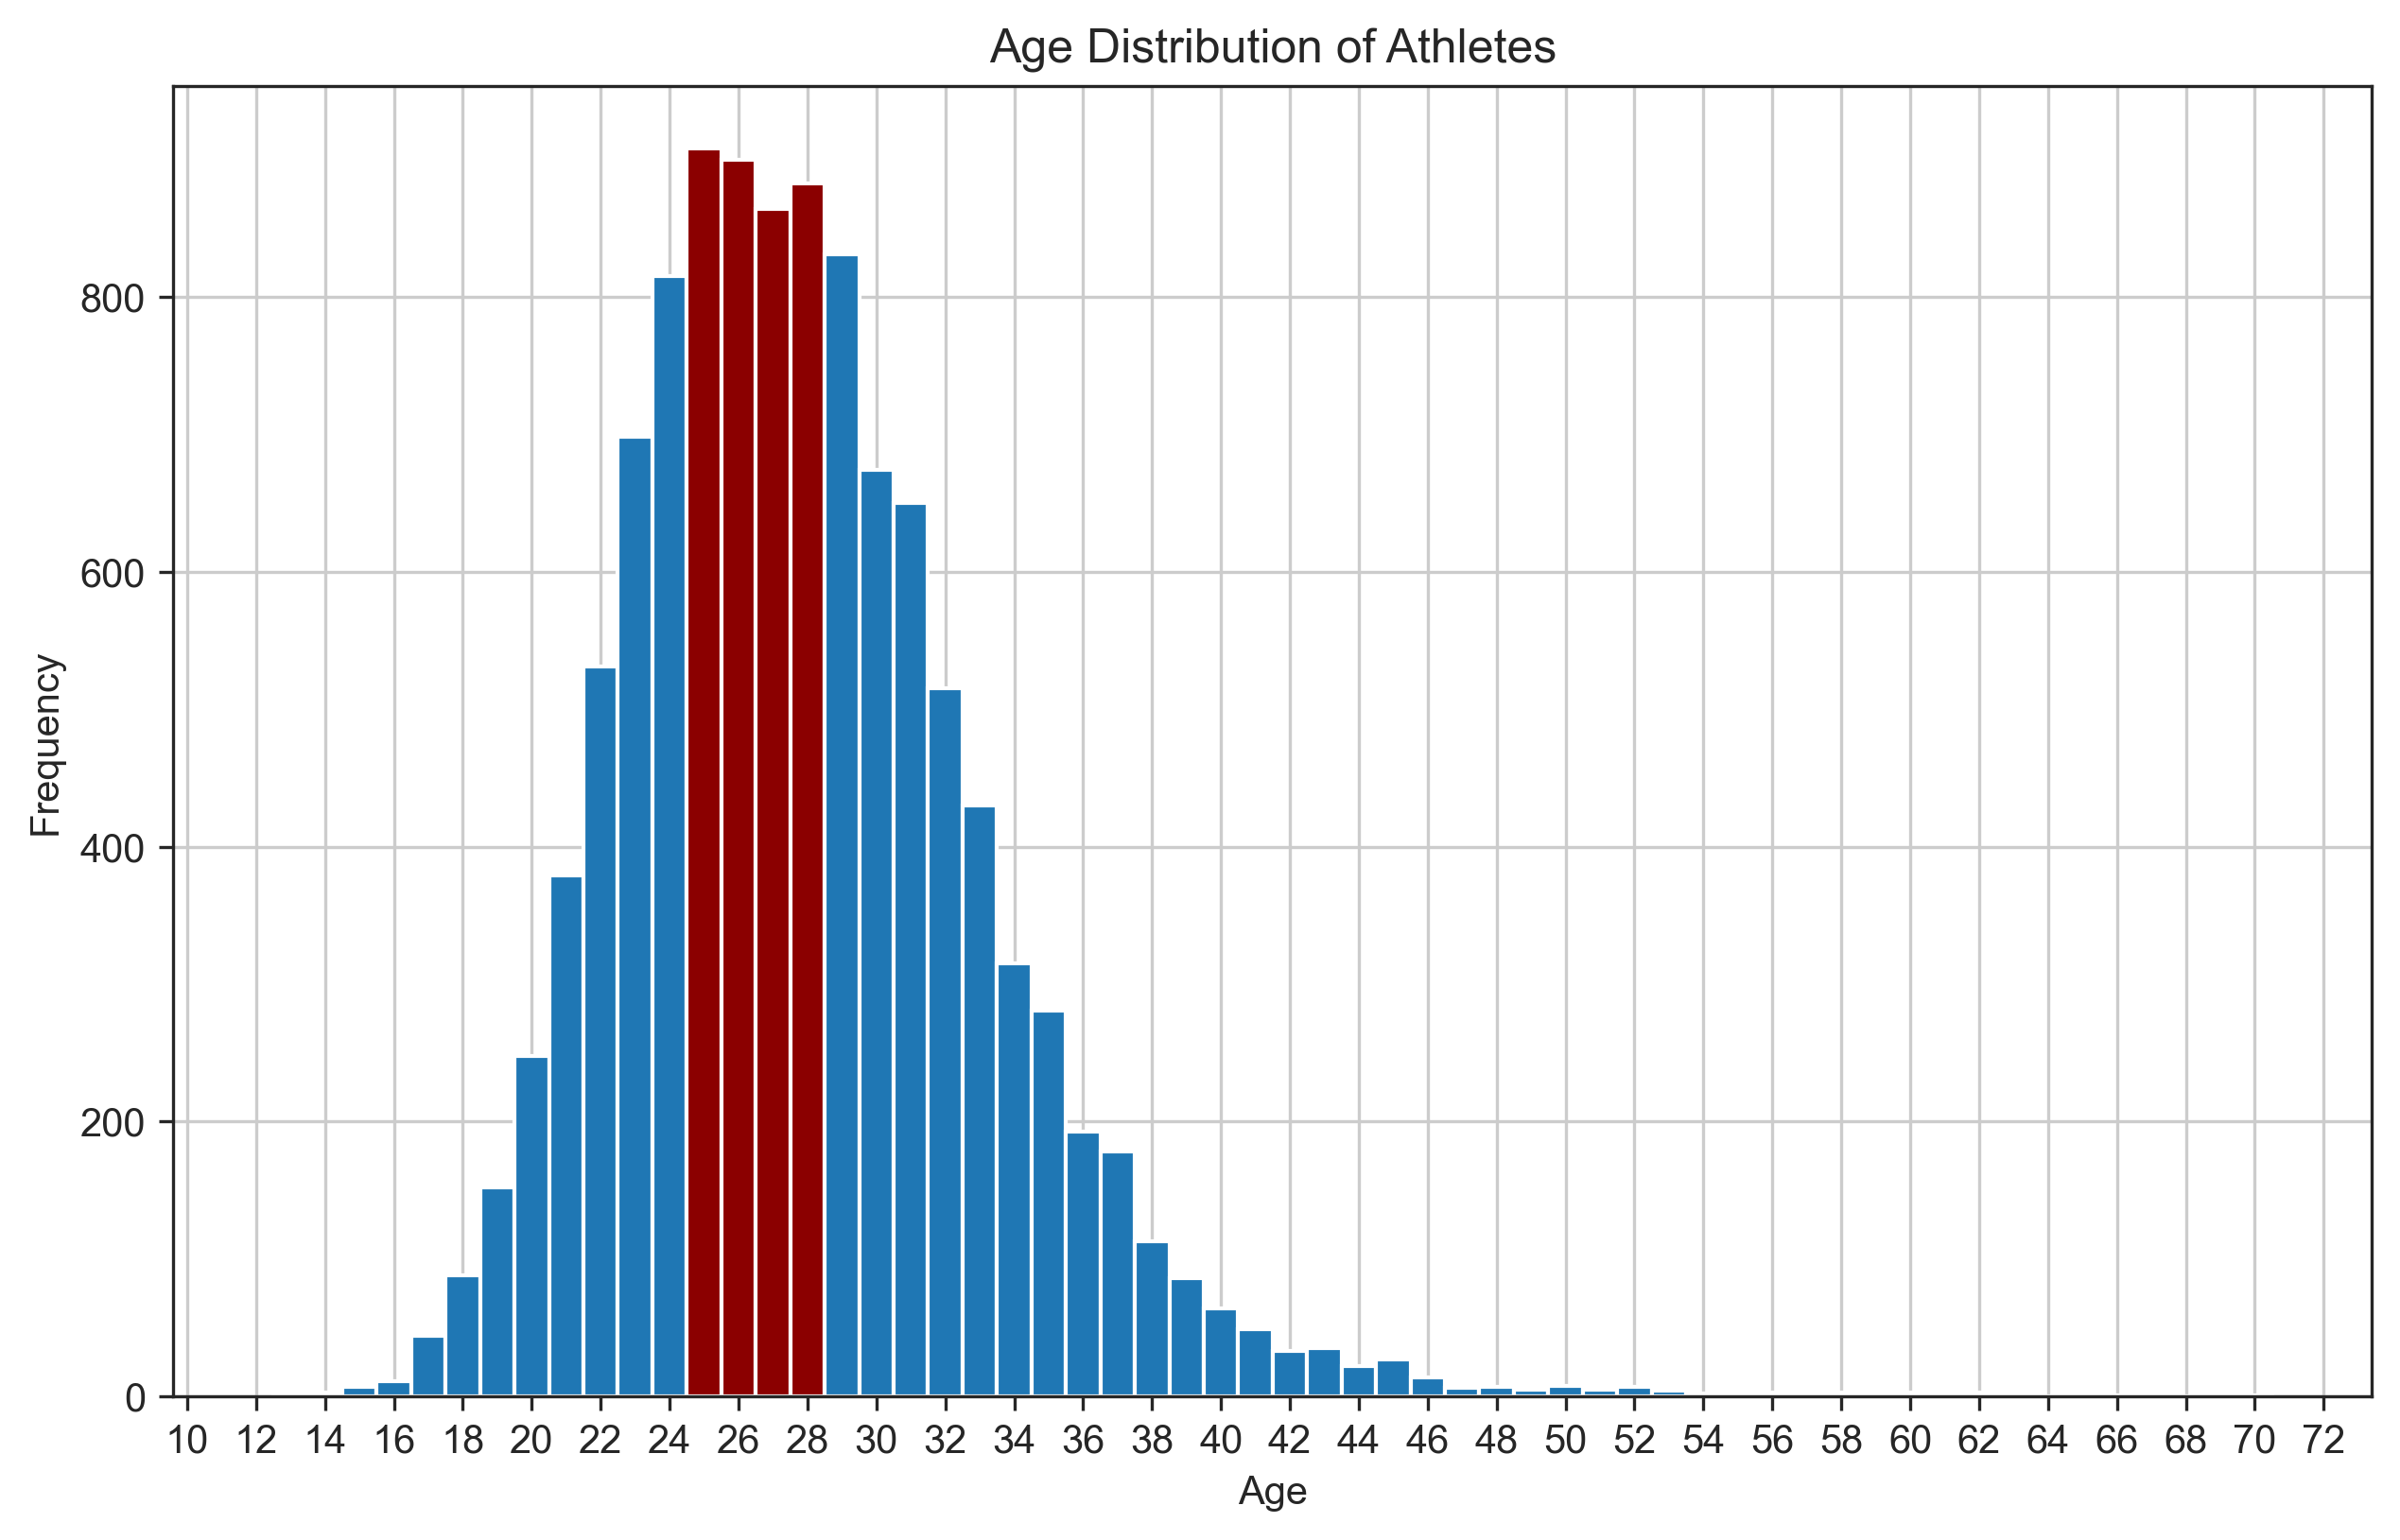

In [45]:
# plot the age distribution of all the athletes
plt.figure(figsize=(10,6), dpi=300)
values, bins, bars = plt.hist(age_df['age'], bins=range(min(age_df['age']), max(age_df['age']) + 1), align='left')
for count, bin_edge, patch in zip(values, bins, bars):
    if count >= max(age_df['age'].value_counts())-50:
        patch.set_facecolor('darkred')  # Change color to red for the highest frequency bar
    elif count == min(age_df['age'].value_counts()):
        patch.set_facecolor('red')


plt.gca().xaxis.set_major_locator(ticker.MultipleLocator(2))
plt.title('Age Distribution of Athletes')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

# Visualize how many athletes are there for each country

In [46]:
# count the occurrences of each country
country_counts = df['country'].value_counts().reset_index()
country_counts.columns = ['country', 'count']
country_counts.head()

,country,count
0,United States,619
1,France,600
2,Australia,475
3,Germany,457
4,Japan,431


In [47]:
# get the latitude and longitude of the country
country_data = '/Users/jhonchristianrozano/Documents/Programming/Python Programming/Exploratory Data Analysis/2024 Olympics/2024 Olympics/world_country_and_usa_states_latitude_and_longitude_values.csv'
country_df = pd.read_csv(country_data)

# slice the dataframe
country_df = country_df[['latitude', 'longitude', 'country']]

In [48]:
df_merged = pd.merge(country_counts, country_df, on='country')
df_merged.head()

,country,count,latitude,longitude
0,United States,619,37.090240,-95.712891
1,France,600,46.227638,2.213749
2,Australia,475,-25.274398,133.775136
3,Germany,457,51.165691,10.451526
4,Japan,431,36.204824,138.252924


In [59]:
n = folium.Map(location=[20,0], tiles="OpenStreetMap", zoom_start=3)
for i in range(0,len(df_merged)):
   popup_text = f"{df_merged.iloc[i]['country']} has {df_merged.iloc[i]['count']} athletes"
   popup = folium.Popup(popup_text, parse_html=True)
   folium.CircleMarker(
      location=[df_merged.iloc[i]['latitude'], df_merged.iloc[i]['longitude']],
      popup=popup,
      radius=float(df_merged.iloc[i]['count'])/10,
      color='#69b3a2',
      fill=True,
      fill_color='#69b3a2',
      fill_opacity=0.6
   ).add_to(n)

n

**We see that USA and France have the biggest number of atheletes**

Note that the map I made is for map visualization purposes only. There are better graphs to use for this.

# Let us see the medals won by each country

In [50]:
medals_df = pd.read_csv('/Users/jhonchristianrozano/Documents/Programming/Python Programming/Exploratory Data Analysis/2024 Olympics/2024 Olympics/medals_total.csv')
medals_df = medals_df[['country_code', 'Gold Medal', 'Silver Medal', 'Bronze Medal']][0:10]
medals_df

,country_code,Gold Medal,Silver Medal,Bronze Medal
0,USA,40,44,42
1,CHN,39,27,24
2,JPN,20,12,13
3,AUS,18,19,16
4,FRA,16,26,22
5,NED,15,7,12
6,GBR,14,21,29
7,KOR,13,9,10
8,ITA,12,13,13
9,GER,11,13,8


In [51]:
df_melted = medals_df.melt(id_vars='country_code', var_name='medal', value_name='count')
df_melted.head()

,country_code,medal,count
0,USA,Gold Medal,40
1,CHN,Gold Medal,39
2,JPN,Gold Medal,20
3,AUS,Gold Medal,18
4,FRA,Gold Medal,16


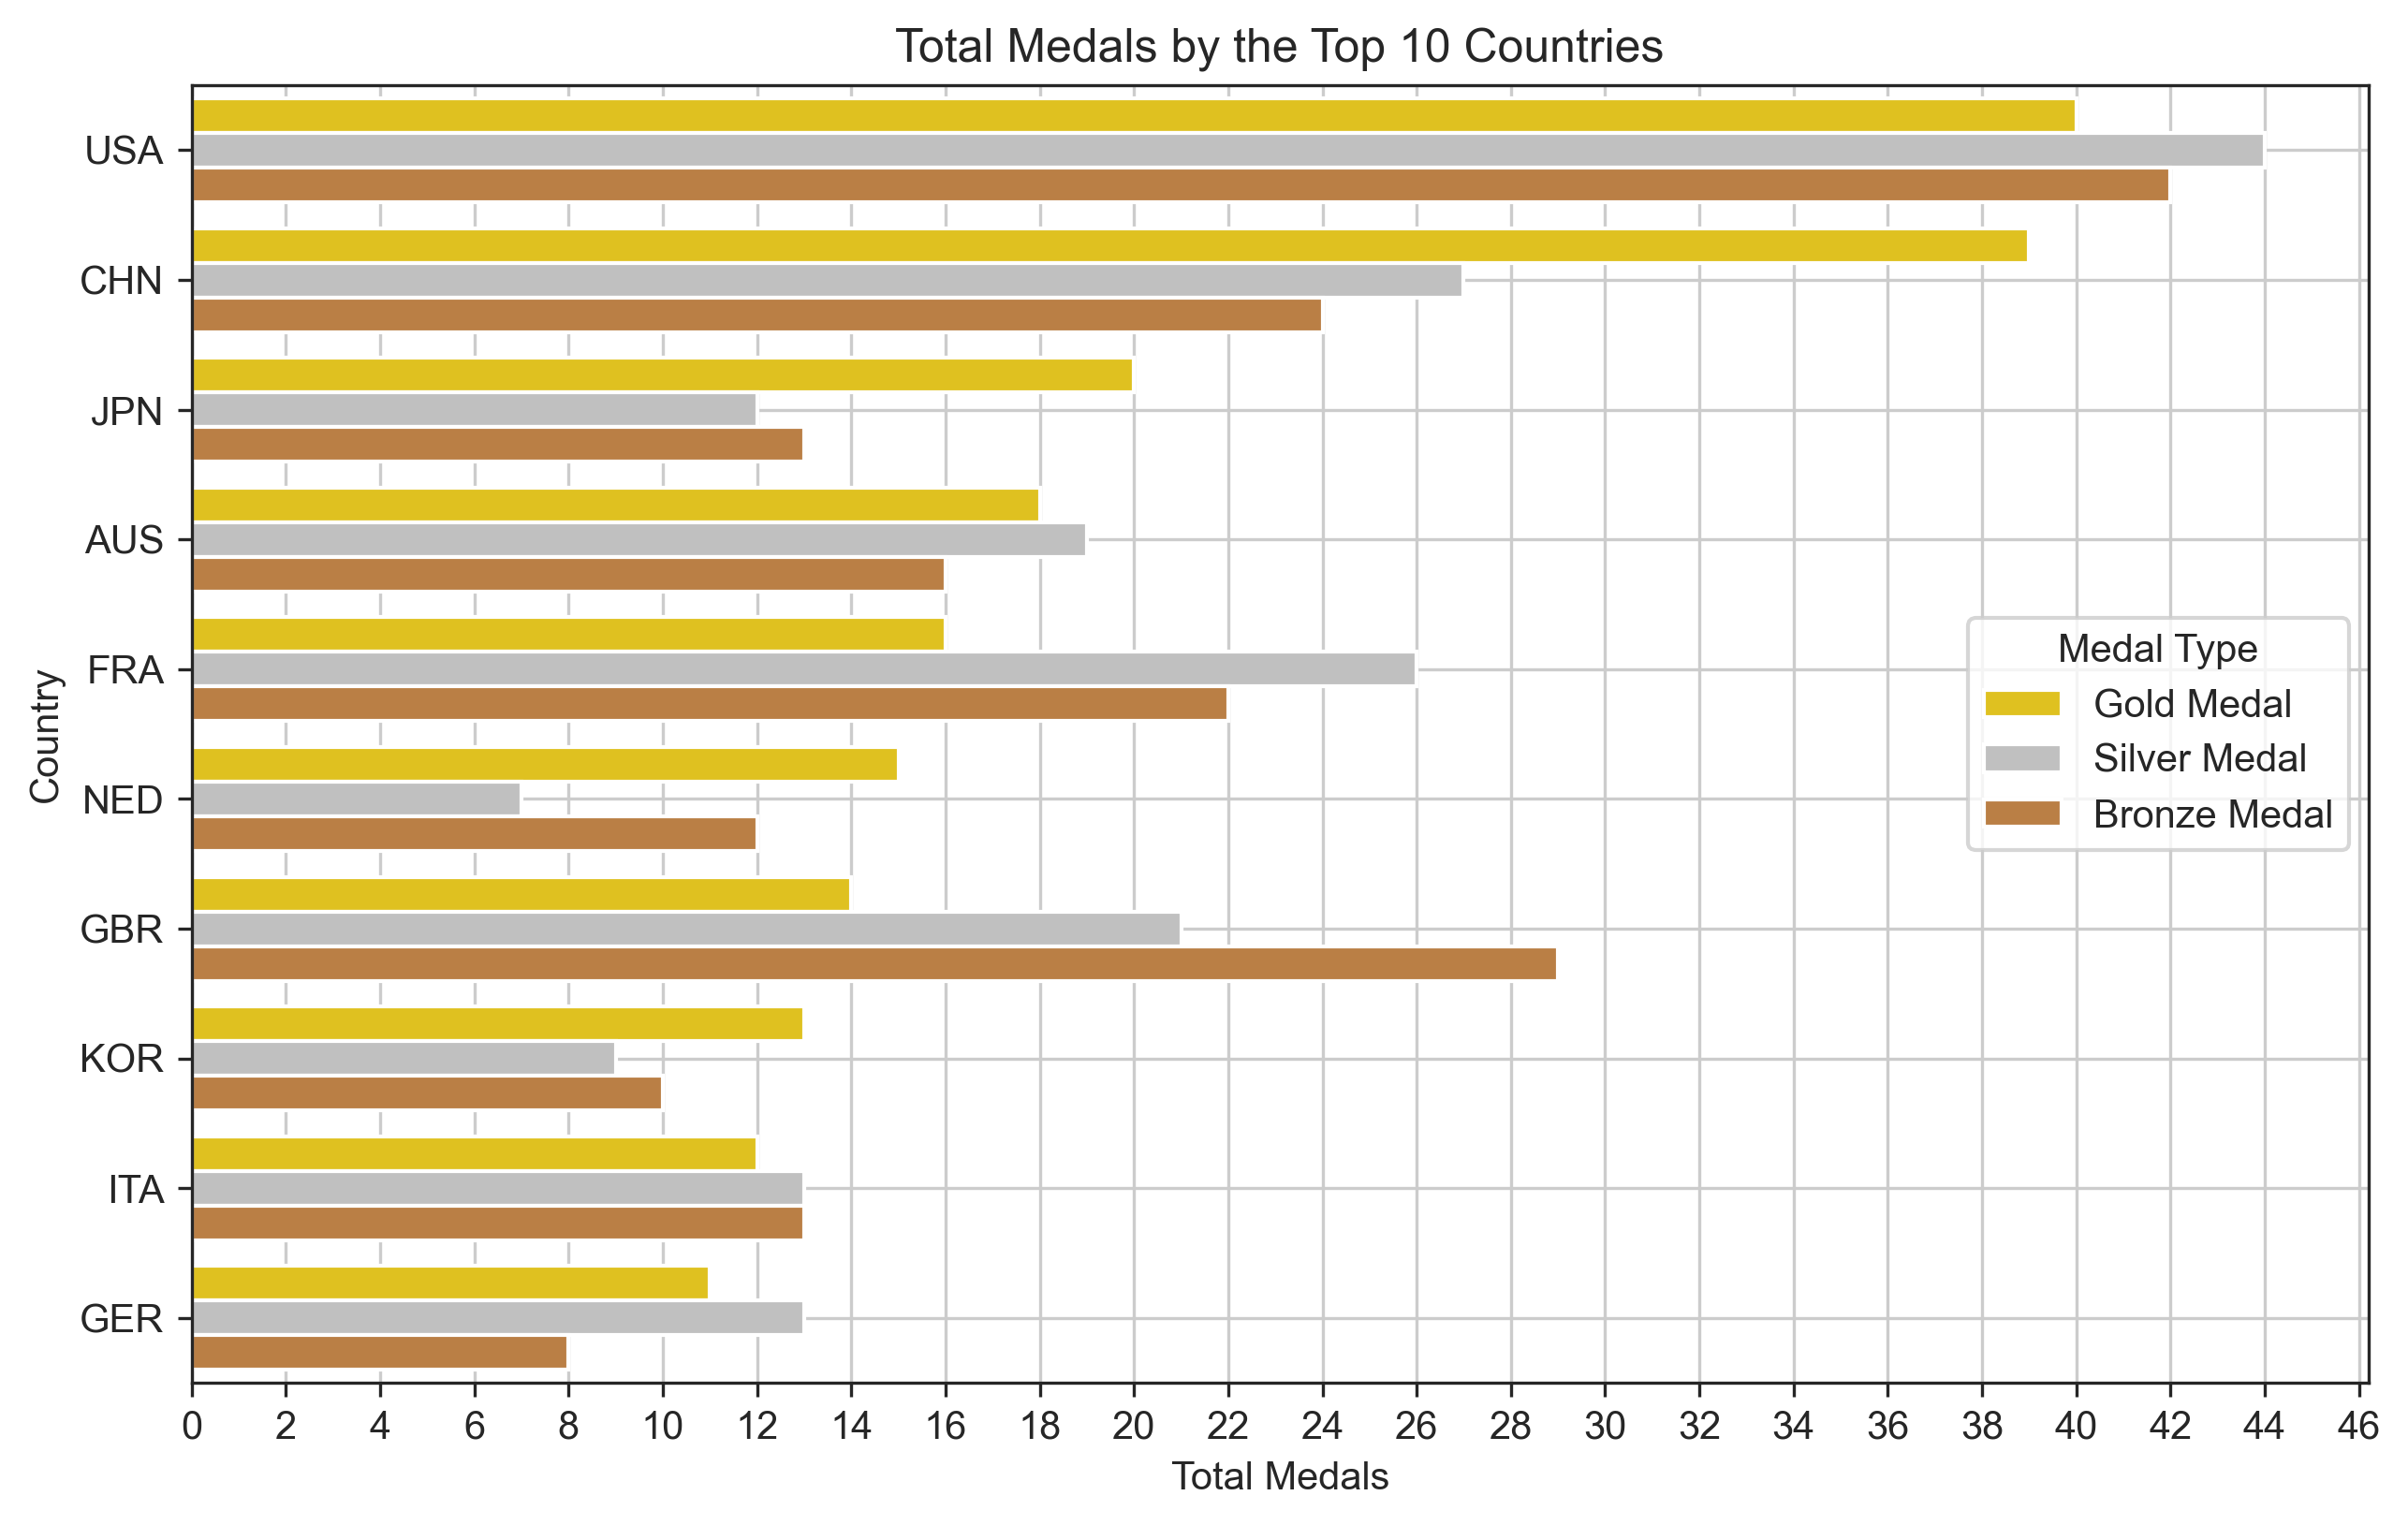

In [52]:
# visualize the medal tally for the top 10 countries
plt.figure(figsize=(10, 6), dpi=300)
sns.barplot(data=df_melted, y='country_code', x='count', hue='medal', palette=['gold', 'silver', '#CD7F32'])

# add labels and title
plt.gca().xaxis.set_major_locator(ticker.MultipleLocator(2))
plt.xlabel('Total Medals')
plt.ylabel('Country')
plt.title('Total Medals by the Top 10 Countries')
plt.legend(title='Medal Type', loc=7)

# show the plot
plt.grid(True)
plt.show()

# Let us see the common reason why they join olympics

In [53]:
nltk.download('wordnet')
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('omw-1.4')

[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/jhonchristianrozano/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/jhonchristianrozano/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     /Users/jhonchristianrozano/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     /Users/jhonchristianrozano/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [54]:
def preprocess_text(text):
    # Remove special characters and convert to lowercase
    text = re.sub(r'[^a-zA-Z\s]', '', str(text).lower())
    
    # Tokenize the text
    tokens = nltk.word_tokenize(text)
    
    # Remove stopwords
    stop_words = set(stopwords.words('english'))
    tokens = [word for word in tokens if word not in stop_words]
    
    # Lemmatize the tokens
    lemmatizer = WordNetLemmatizer()
    tokens = [lemmatizer.lemmatize(word) for word in tokens]
    
    # Join the tokens back into a single string
    cleaned_text = ' '.join(tokens)
    
    return cleaned_text

def word_cloud(vectorized_text):
    feature_names = tfidf.get_feature_names_out() 
    tfidf_scores = vectorized_text.sum(axis=0).A1
    word_scores = dict(zip(feature_names, tfidf_scores))
    wordcloud = WordCloud(width=1920, height=1080, max_words=100, background_color='white').generate_from_frequencies(word_scores)
    return wordcloud

In [55]:
processed_text = df.influence[df['influence'].notnull()].apply(lambda x: preprocess_text(x))

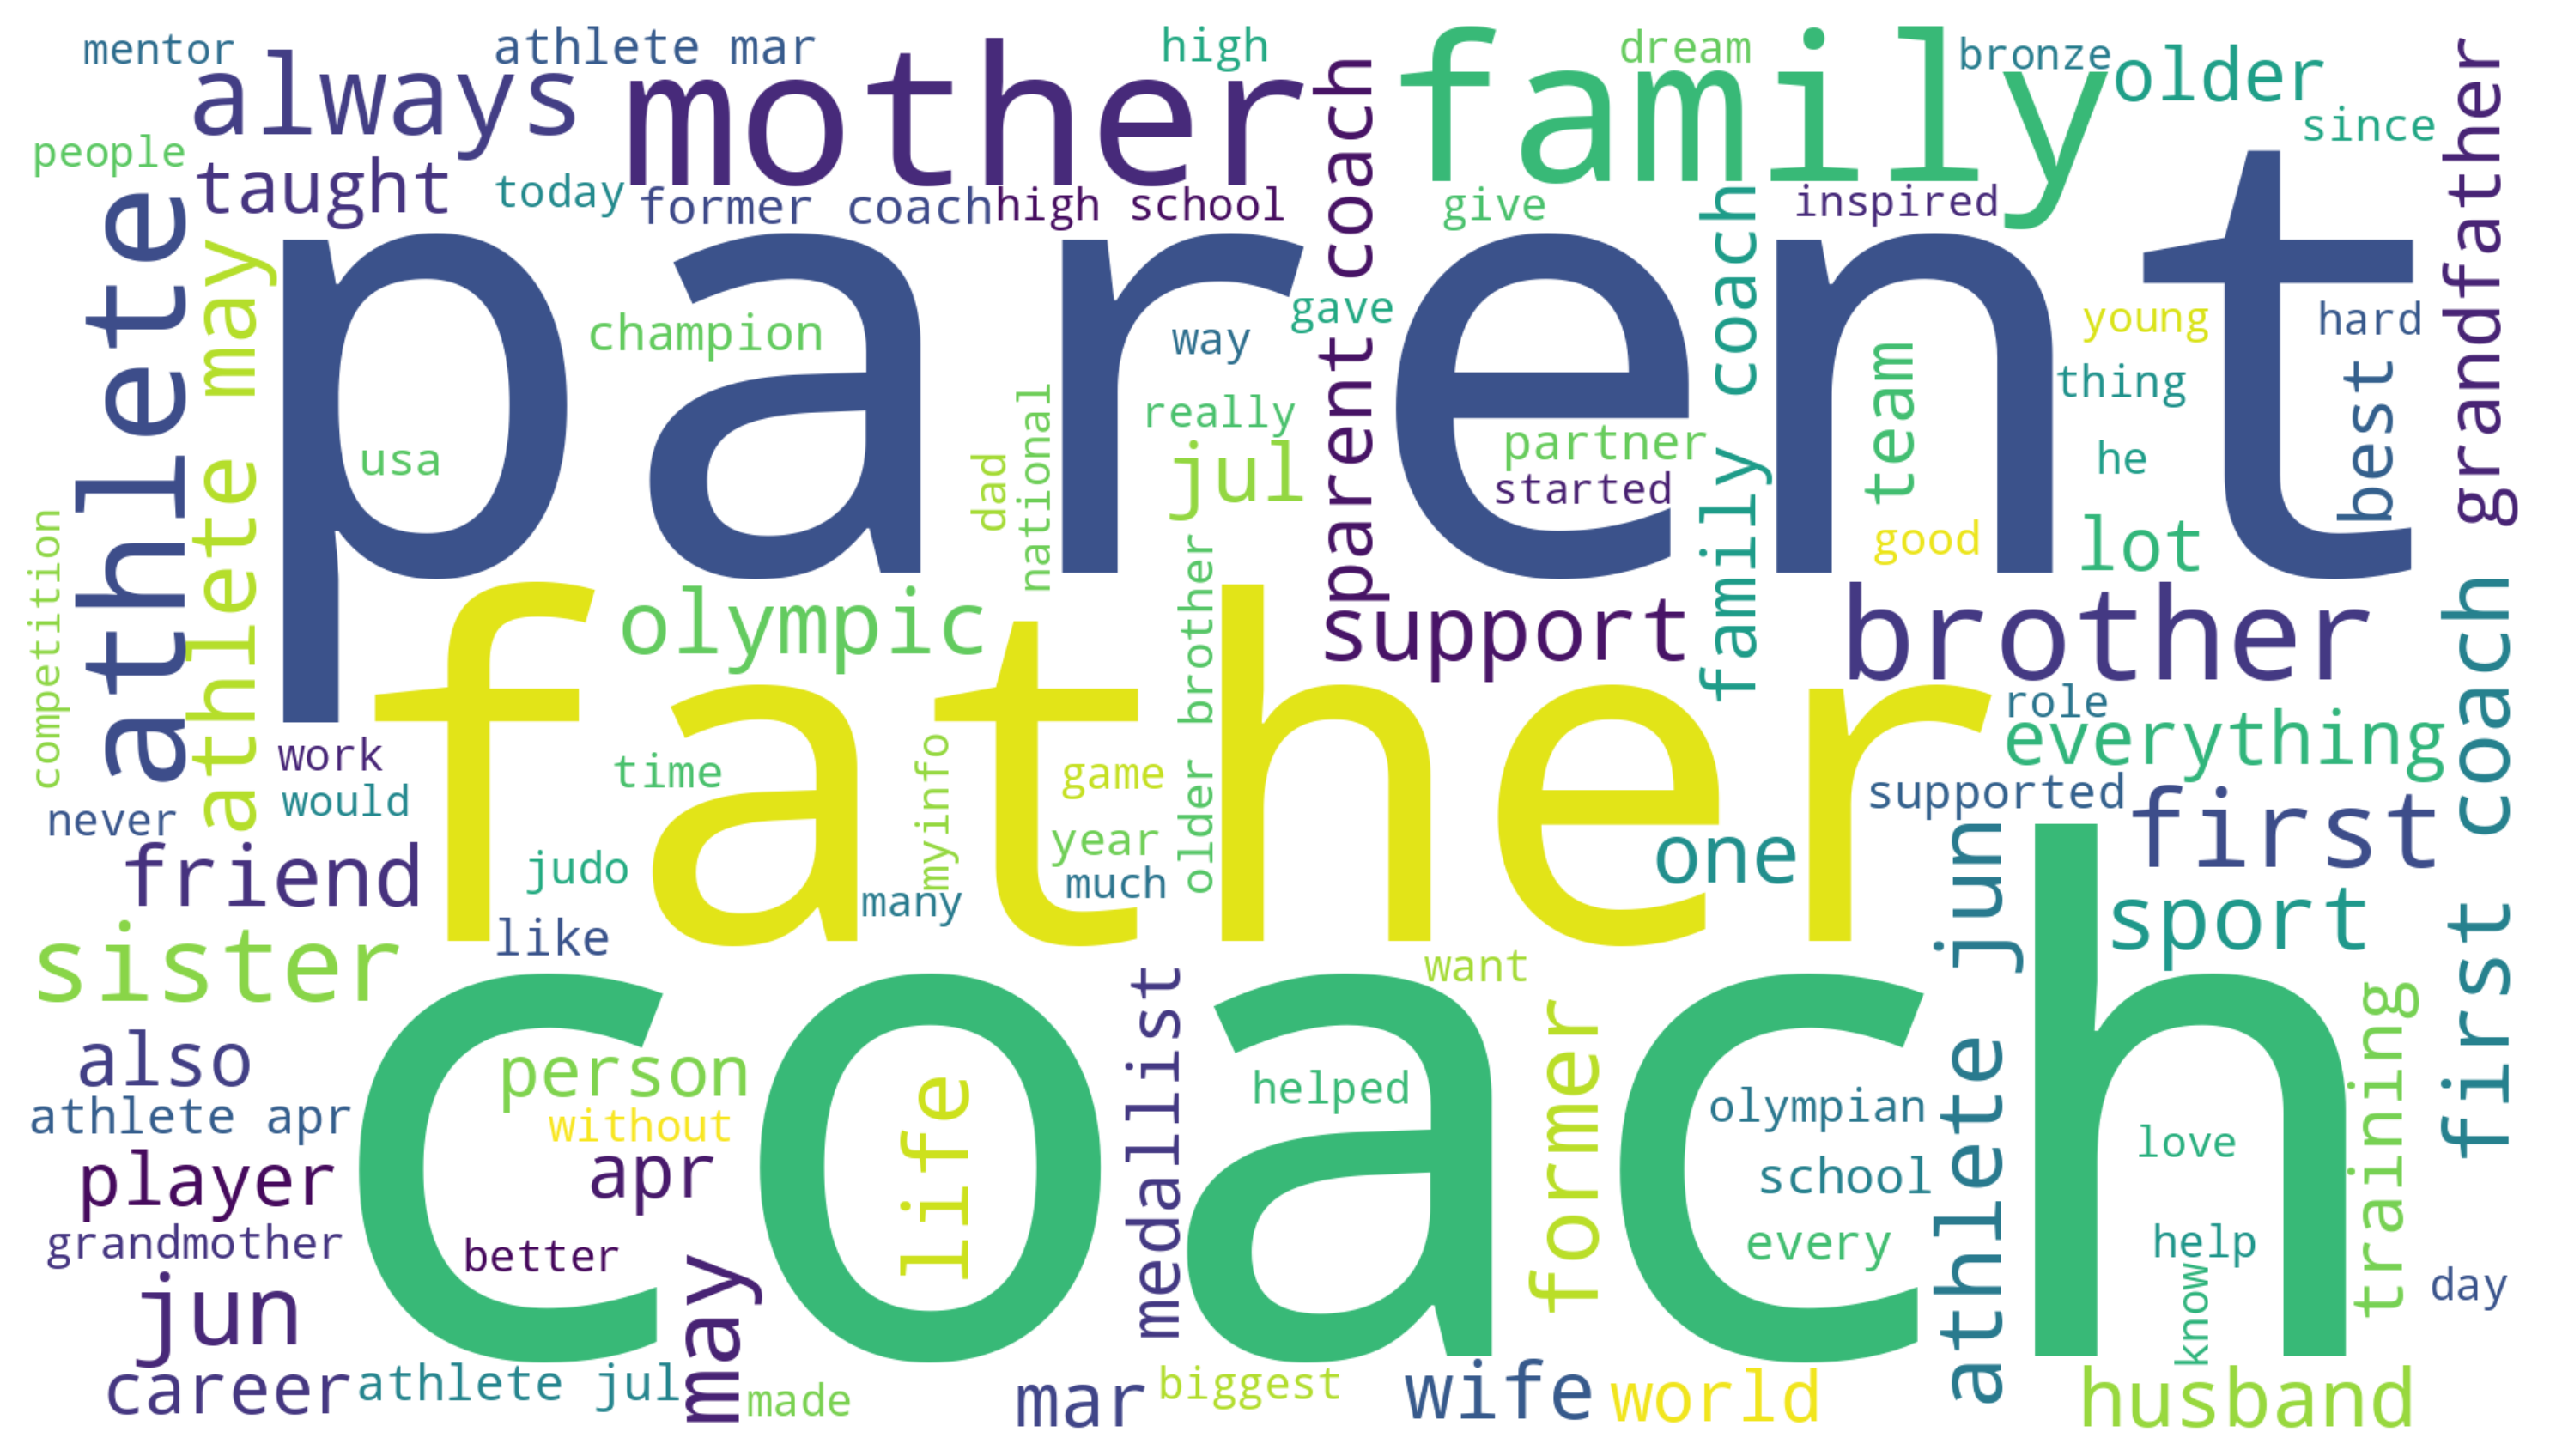

In [56]:
tfidf = TfidfVectorizer(ngram_range=(1,2), min_df=.01)
vectorized_text = tfidf.fit_transform(processed_text)
wordcloud = word_cloud(vectorized_text)

plt.figure(figsize=(10,6), dpi=300)
plt.imshow(wordcloud, interpolation='bilinear')        
#plt.title('Can you share any thoughts or feedback you may have on the event in relation to your ratings above?')        
plt.axis('off')

plt.tight_layout()
plt.show()

# Let us look at the combined data from the past

In [57]:
# 2024 data count of gender
male_count = df[df['gender']=='Male']
male_count = male_count.drop_duplicates(subset=['name'])
print(male_count['gender'].count())

female_count = df[df['gender']=='Female']
female_count = female_count.drop_duplicates(subset=['name'])
print(female_count['gender'].count())

5651
5449


In [58]:
past_df.head()

NameError: name 'past_df' is not defined

In [ ]:
past_df = pd.read_csv("/Users/jhonchristianrozano/Documents/Programming/Python Programming/2024 Olympics/Past Olympics/OlympicAthletes.csv")
past_df = past_df.loc[(past_df['Season'] == "Summer") & ((past_df['Sex'] == 'M') | (past_df['Sex']=='W'))]
#print(past_df['Sex'].duplicated().sum())
past_df = past_df.drop_duplicates(subset=['Athlete'])

gender_past_df = past_df[['Year', 'Sex']].groupby(['Year']).value_counts().reset_index()
gender_past_df.loc[len(gender_past_df)] = [2024, 'M', male_count['gender'].count()]
gender_past_df.loc[len(gender_past_df)] = [2024, 'W', female_count['gender'].count()]

gender_past_df['Sex'] = gender_past_df['Sex'].replace('W', 'Female')
gender_past_df['Sex'] = gender_past_df['Sex'].replace('M', 'Male')
gender_past_df.head()

,Year,Sex,count
0,1896,Male,237
1,1900,Male,1394
2,1900,Female,16
3,1904,Male,1164
4,1904,Female,6


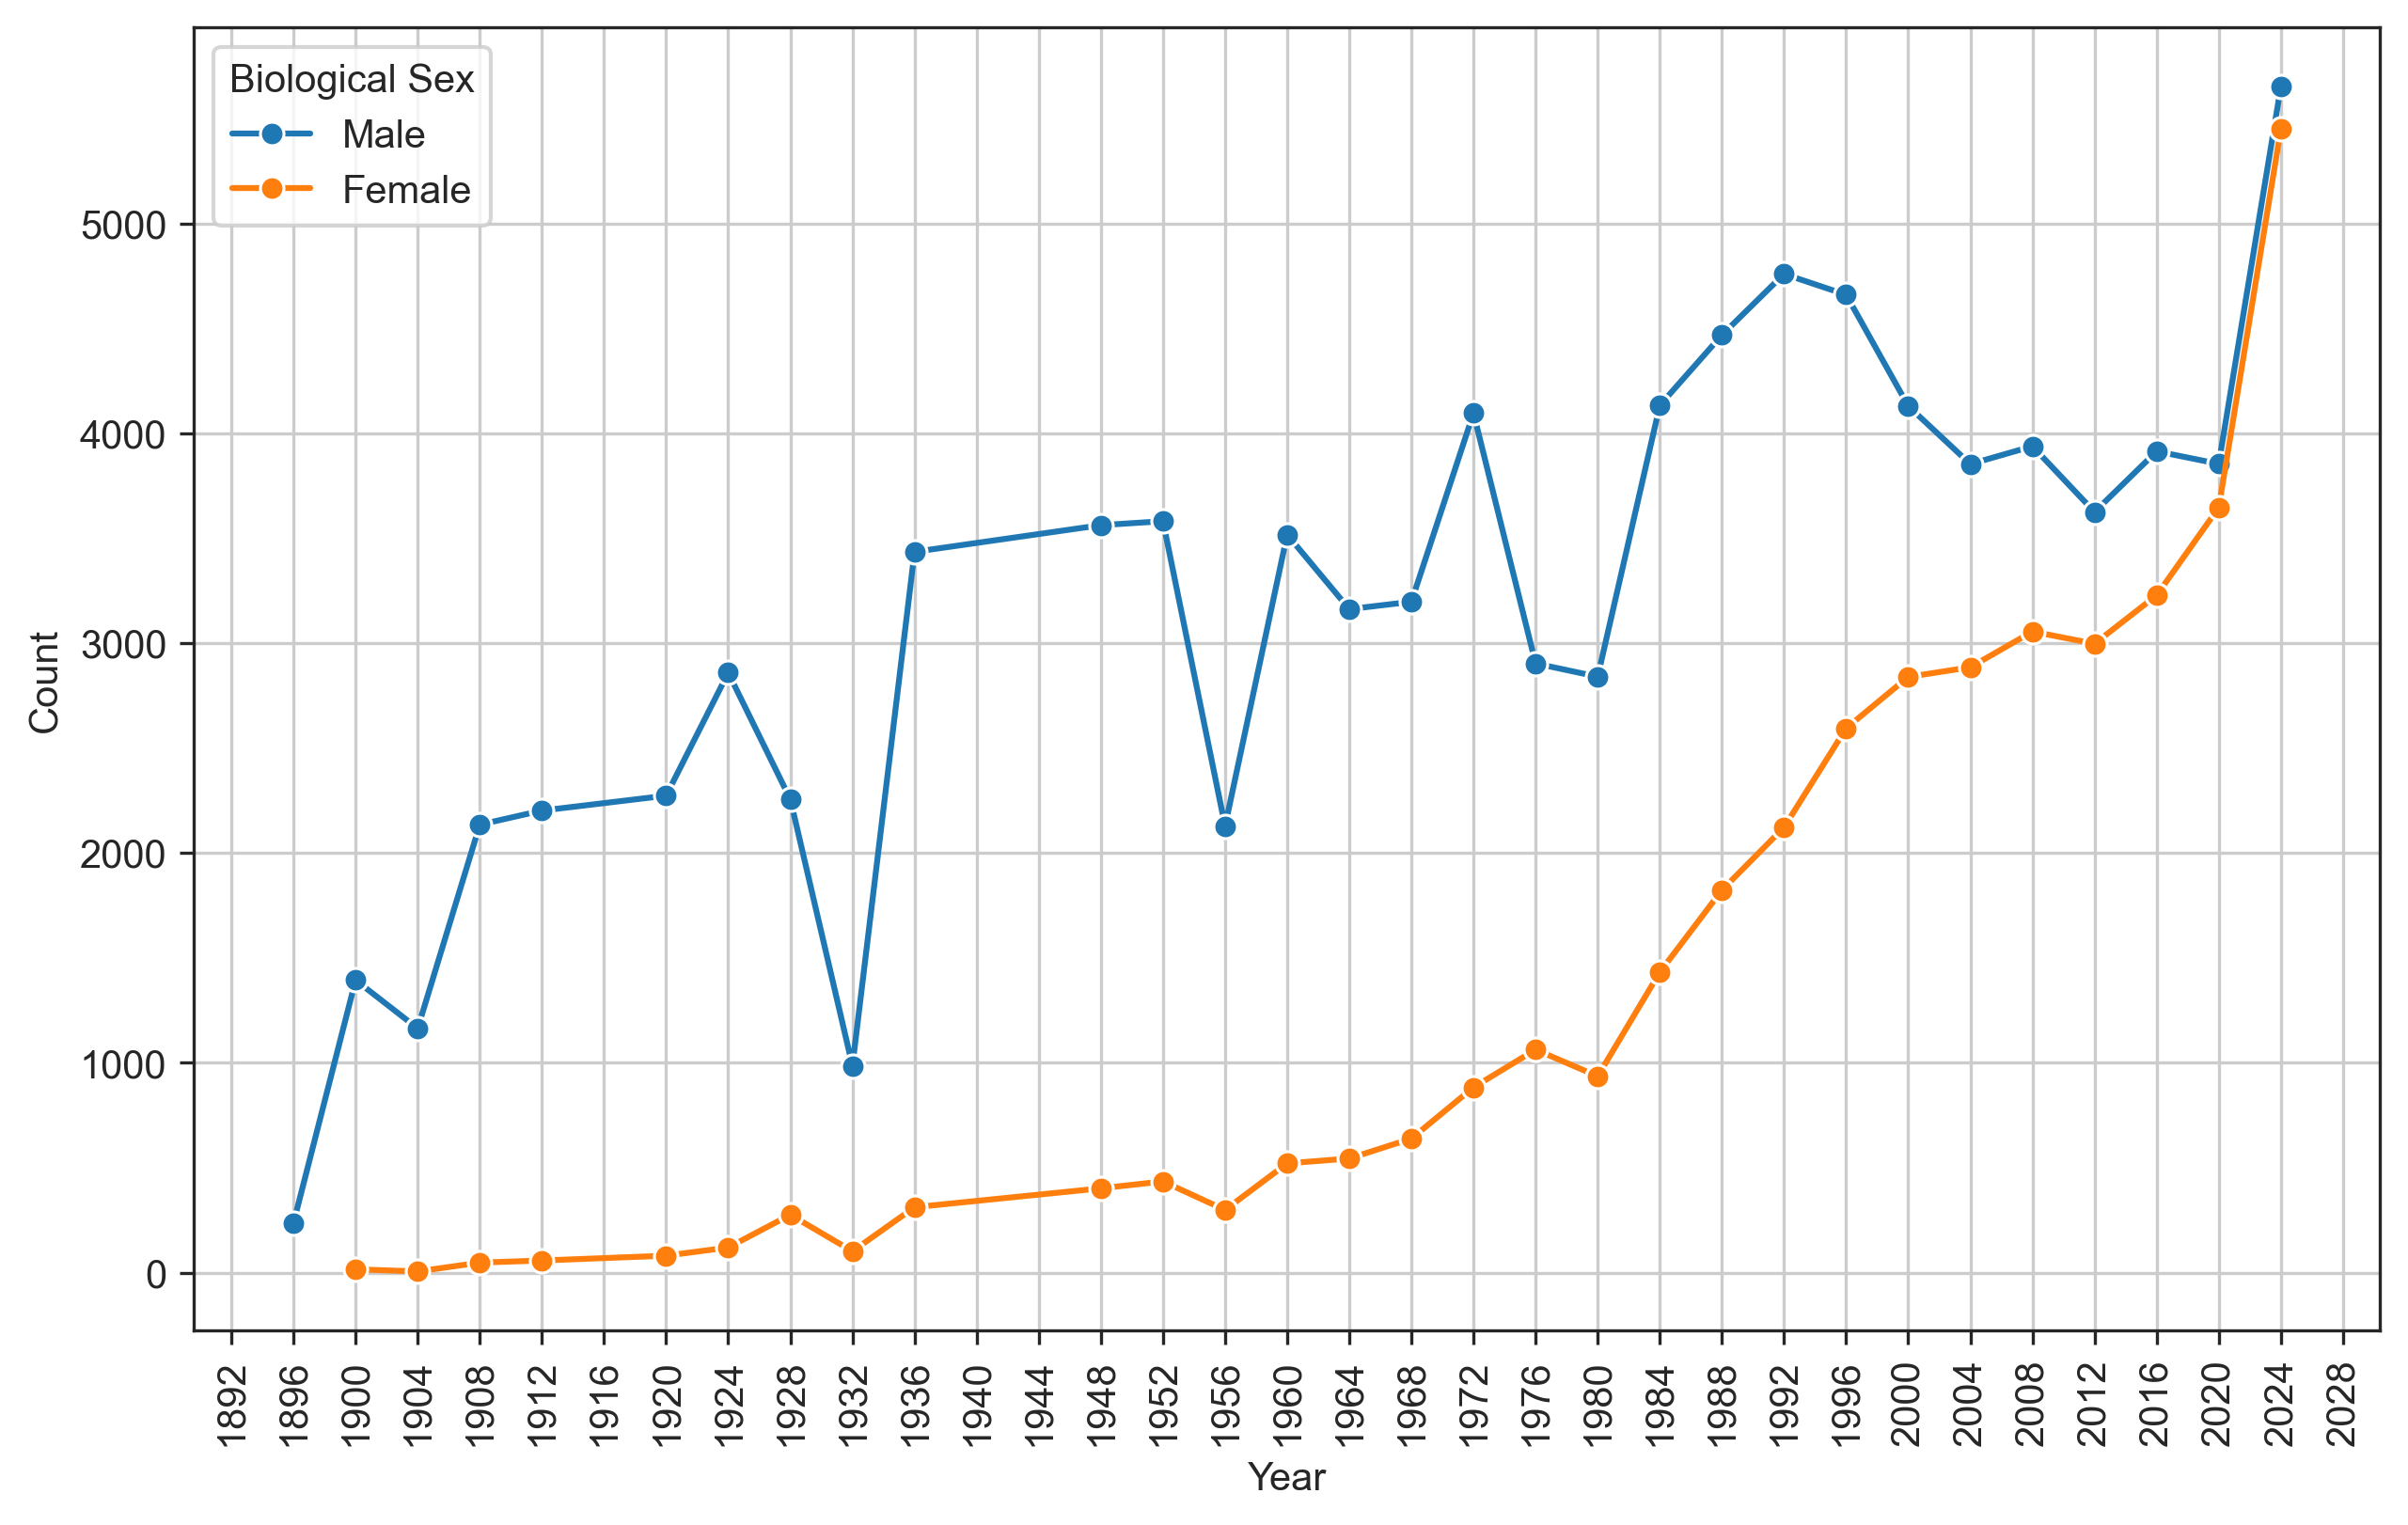

In [ ]:
# let us visualize
plt.figure(figsize=(10, 6), dpi=300)
sns.lineplot(x='Year', y='count', hue='Sex', data=gender_past_df, marker='o')

plt.legend(title='Biological Sex')
plt.xticks(list(range(1892, 2028 + 1, 4)), rotation=90)
plt.grid(True)
plt.xlabel('Year')
plt.ylabel('Count')
# Show the plot
plt.show()

# Let us look at the games this 2024 olympics

In [ ]:
#exploded_df=df.set_index(['disciplines', 'events'])
exploded_df = df.explode('events')

# Let us look at the performances of the athletes

In [ ]:
athletics_df = pd.read_csv('/Users/jhonchristianrozano/Documents/Programming/Python Programming/2024 Olympics/2024 Olympics/results/Athletics.csv')
athletics_df.head()

,date,stage_code,event_code,event_name,event_stage,stage,stage_status,gender,discipline_name,discipline_code,venue,participant_code,participant_name,participant_type,participant_country_code,participant_country,rank,result,result_type,result_IRM,result_diff,qualification_mark,start_order,bib
0,2024-08-03T17:48:06+02:00,ATHX4X400M------------RND1000200--,ATHX4X400M,4 x 400m Relay Mixed,4 x 400m Relay Mixed Round 1 - Heat 2,Round 1 - Heat 2,FINISHED,X,Athletics,ATH,Stade de France,ATHX4X400M--GBR01,Great Britain,Team,GBR,Great Britain,1.0,3:10.61,TIME,NaN,NaN,Q,4,NaN
1,2024-08-03T17:48:06+02:00,ATHX4X400M------------RND1000200--,ATHX4X400M,4 x 400m Relay Mixed,4 x 400m Relay Mixed Round 1 - Heat 2,Round 1 - Heat 2,FINISHED,X,Athletics,ATH,Stade de France,ATHX4X400M--NED01,Netherlands,Team,NED,Netherlands,2.0,3:10.81,TIME,NaN,NaN,Q,6,NaN
2,2024-08-03T17:48:06+02:00,ATHX4X400M------------RND1000200--,ATHX4X400M,4 x 400m Relay Mixed,4 x 400m Relay Mixed Round 1 - Heat 2,Round 1 - Heat 2,FINISHED,X,Athletics,ATH,Stade de France,ATHX4X400M--ITA01,Italy,Team,ITA,Italy,3.0,3:11.59,TIME,NaN,NaN,Q,3,NaN
3,2024-08-03T17:48:06+02:00,ATHX4X400M------------RND1000200--,ATHX4X400M,4 x 400m Relay Mixed,4 x 400m Relay Mixed Round 1 - Heat 2,Round 1 - Heat 2,FINISHED,X,Athletics,ATH,Stade de France,ATHX4X400M--NGR01,Nigeria,Team,NGR,Nigeria,4.0,3:11.99,TIME,NaN,NaN,NaN,5,NaN
4,2024-08-03T17:48:06+02:00,ATHX4X400M------------RND1000200--,ATHX4X400M,4 x 400m Relay Mixed,4 x 400m Relay Mixed Round 1 - Heat 2,Round 1 - Heat 2,FINISHED,X,Athletics,ATH,Stade de France,ATHX4X400M--IRL01,Ireland,Team,IRL,Ireland,5.0,3:12.67,TIME,NaN,NaN,NaN,7,NaN


In [ ]:
athletics_df.columns

Index(['date', 'stage_code', 'event_code', 'event_name', 'event_stage',
       'stage', 'stage_status', 'gender', 'discipline_name', 'discipline_code',
       'venue', 'participant_code', 'participant_name', 'participant_type',
       'participant_country_code', 'participant_country', 'rank', 'result',
       'result_type', 'result_IRM', 'result_diff', 'qualification_mark',
       'start_order', 'bib'],
      dtype='object')

In [ ]:
athletics_df['event_stage'].unique()

In [ ]:
mens100m_df = athletics_df.loc[athletics_df['event_stage'] == "Men's 100m Final"]
mens100m_df = mens100m_df[['participant_code', 'gender', 'participant_country', 'date', 'event_stage', 'stage',  'rank', 'start_order', 'result']]
mens100m_df.head()

,participant_code,gender,participant_country,date,event_stage,stage,rank,start_order,result
221,1960173,M,United States,2024-08-04T21:56:51+02:00,Men's 100m Final,Final,1.0,7,9.79
222,1980161,M,Jamaica,2024-08-04T21:56:51+02:00,Men's 100m Final,Final,2.0,4,9.79
223,1960958,M,United States,2024-08-04T21:56:51+02:00,Men's 100m Final,Final,3.0,3,9.81
224,1981055,M,South Africa,2024-08-04T21:56:51+02:00,Men's 100m Final,Final,4.0,5,9.82
225,1552167,M,Italy,2024-08-04T21:56:51+02:00,Men's 100m Final,Final,5.0,9,9.85


In [ ]:
# merge the athletes csv to the dataframe to get their names
names_df = df[['code', 'name']]
names_df.rename(columns={'code': 'participant_code'}, inplace=True)

# make them string
names_df['participant_code'] = pd.to_numeric(names_df['participant_code'], errors='coerce').astype('Int64')
mens100m_df['participant_code'] = pd.to_numeric(mens100m_df['participant_code'], errors='coerce').astype('Int64')

mens100m_merged_df = pd.merge(mens100m_df, names_df, on='participant_code', how='left')

/var/folders/fy/zvqy_7710b1br2kprlbtbpf00000gn/T/ipykernel_28276/2735582791.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  names_df.rename(columns={'code': 'participant_code'}, inplace=True)
/var/folders/fy/zvqy_7710b1br2kprlbtbpf00000gn/T/ipykernel_28276/2735582791.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  names_df['participant_code'] = pd.to_numeric(names_df['participant_code'], errors='coerce').astype('Int64')
